In [1]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import Levenshtein
from sklearn.metrics import accuracy_score
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os
import matplotlib.pyplot as plt
import random

c:\Users\jacob\anaconda3\envs\gsr\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.cuda.empty_cache()

In [7]:
class LicensePlateOCRDataset(Dataset):
    def __init__(self, img_dir, annotations_file, processor, subsample_size=None):
        self.img_dir = img_dir
        self.processor = processor
        self.annotations = pd.read_csv(annotations_file, header=None)

        # Ensure correcta column names
        self.annotations.columns = ["image_filename", "label"]

        # Fix incorrect paths
        self.annotations["image_filename"] = self.annotations["image_filename"].str.replace("train/train/", "train/")

        # Filter missing images
        self.annotations = self.annotations[self.annotations["image_filename"].apply(
            lambda x: os.path.exists(os.path.join(img_dir, x))
        )].reset_index(drop=True)

        # Apply subsampling if needed
        if subsample_size and len(self.annotations) > subsample_size:
            self.annotations = self.annotations.sample(n=subsample_size, random_state=42).reset_index(drop=True)

        if len(self.annotations) == 0:
            raise ValueError(f"Error: No valid images found in {img_dir} using {annotations_file}!")

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        filename = self.annotations.iloc[idx, 0]
        img_path = os.path.join(self.img_dir, filename)

        if not os.path.exists(img_path):
            print(f"Warning: File {img_path} not found, skipping...")
            return None, None

        # Load image and convert to RGB
        image = Image.open(img_path).convert("RGB")

        # **Ensure image is correctly scaled in [0,1]**
        processed_image = self.processor(image, return_tensors="pt").pixel_values[0]  # Shape: (C, H, W)
        processed_image = torch.clamp(processed_image, 0, 1)  # Fix range issue

        label = self.annotations.iloc[idx, 1]
        return processed_image, label

In [8]:
# Load Processor and Model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")

# **Fix the missing decoder start token**
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id  # Set decoder start token
model.config.pad_token_id = processor.tokenizer.pad_token_id  # Ensure padding token is set

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.46.2"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linea

In [9]:
# Load Data
train_dataset = LicensePlateOCRDataset("../data/arg_plate_dataset/", "../data/arg_plate_dataset/train_anotaciones.csv", processor, subsample_size=300)
valid_dataset = LicensePlateOCRDataset("../data/arg_plate_dataset/", "../data/arg_plate_dataset/valid_anotaciones.csv", processor, subsample_size=50)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

In [7]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
num_epochs = 10

In [7]:
# Training Loop
for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        inputs = processor(images, return_tensors="pt", padding=True).to(device)
        labels = processor.tokenizer(labels, return_tensors="pt", padding=True).input_ids.to(device)

        optimizer.zero_grad()
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}")

It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


Epoch [1/10], Loss: 18.34518051147461
Epoch [2/10], Loss: 7.8963751792907715
Epoch [3/10], Loss: 6.065418720245361
Epoch [4/10], Loss: 4.3688178062438965
Epoch [5/10], Loss: 4.612777233123779
Epoch [6/10], Loss: 3.8927624225616455
Epoch [7/10], Loss: 4.674442768096924
Epoch [8/10], Loss: 4.1015143394470215
Epoch [9/10], Loss: 4.67812442779541
Epoch [10/10], Loss: 4.442720413208008


In [11]:
model.save_pretrained("models/trocr_license_plate")
processor.save_pretrained("models/trocr_license_plate")

[]

### Test Fine Tuned Model

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved model and processor
model = VisionEncoderDecoderModel.from_pretrained("../models/trocr_license_plate").to(device)
processor = TrOCRProcessor.from_pretrained("../models/trocr_license_plate")

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.46.2"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

In [3]:
def recognize_license_plate(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")

    # Process image for the model
    inputs = processor(image, return_tensors="pt").to(device)

    # Generate prediction
    with torch.no_grad():
        output_ids = model.generate(**inputs)

    # Decode the predicted text
    predicted_text = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    
    return predicted_text

In [4]:
valid_folder = "../data/arg_plate_dataset/valid/"

# Get all image files from the folder
all_images = [os.path.join(valid_folder, f) for f in os.listdir(valid_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

c:\Users\jacob\anaconda3\envs\gsr\Lib\site-packages\transformers\generation\utils.py:1375: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


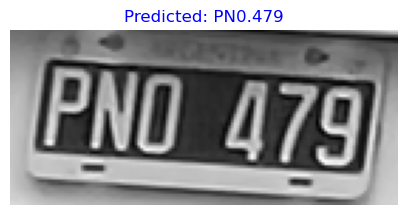

License Plate (2020-18-07_1556-16_80_433.png): PN0.479


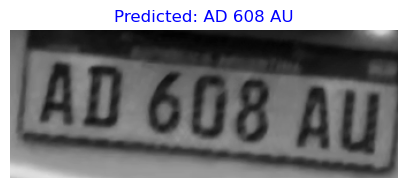

License Plate (2020-23-07_1640-30_71_567.png): AD 608 AU


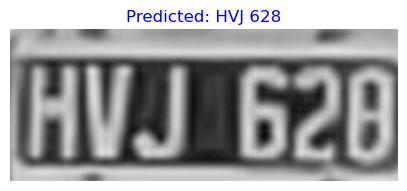

License Plate (2020-18-08_1737-47_37_3259_cropped.png): HVJ 628


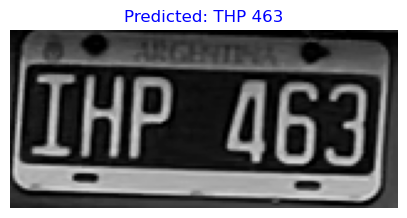

License Plate (2020-24-07_1117-37_26_903.png): THP 463


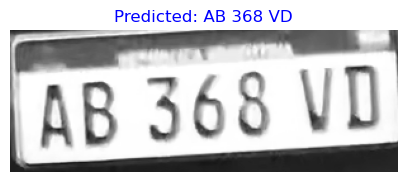

License Plate (2020-04-08_1613-53_31_209.png): AB 368 VD


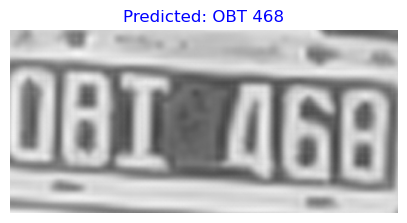

License Plate (2020-18-08_1737-53_73_8118_cropped.png): OBT 468


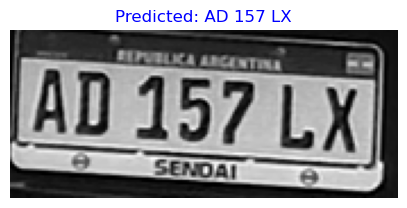

License Plate (2020-18-07_1439-01_76_961.png): AD 157 LX


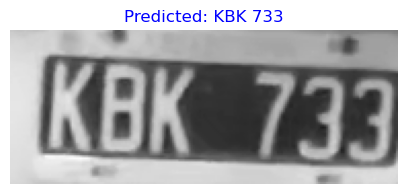

License Plate (2020-18-07_1722-40_85_43.png): KBK 733


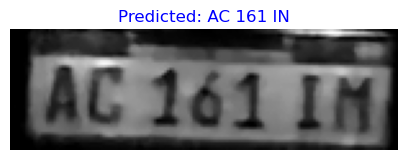

License Plate (2020-02-08_1930-11_95_671.png): AC 161 IN


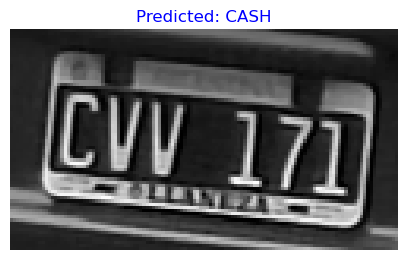

License Plate (2020-18-07_1442-55_75_156.png): CASH


In [ ]:
# Select 10 random images
random_images = random.sample(all_images, min(len(all_images), 10)) 

# Run OCR on selected images
for img_path in random_images:
    # Recognize license plate text
    result = recognize_license_plate(img_path)

    # Display the image
    image = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")  # Hide axes
    plt.title(f"Predicted: {result}", fontsize=12, color="blue")
    plt.show()

    # Print output
    print(f"License Plate ({os.path.basename(img_path)}): {result}")

In [11]:
model.eval()

predictions = []
ground_truths = []

# Disable gradient computation for inference
with torch.no_grad():
    for batch in valid_loader:  
        # Unpack the batch properly
        images, labels = batch  # Ensure correct format
        images = images.to(device)  # Move images to GPU/CPU
        
        # Hugging Face models require input through `.generate()`
        outputs = model.generate(images)

        # Convert outputs to text
        decoded_preds = processor.batch_decode(outputs, skip_special_tokens=True)
        
        # Store predictions and ground truths
        predictions.extend(decoded_preds)
        ground_truths.extend(labels)

c:\Users\jacob\anaconda3\envs\gsr\Lib\site-packages\transformers\generation\utils.py:1375: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [12]:
predictions = [''.join(p.split()) for p in predictions]

In [ ]:
def compute_cer(predictions, ground_truths):
    total_chars = sum(len(gt) for gt in ground_truths)
    total_edits = sum(Levenshtein.distance(pred, gt) for pred, gt in zip(predictions, ground_truths))
    return total_edits / total_chars  # CER (Lower is better)

cer_score = compute_cer(predictions, ground_truths)
print(f'Character Error Rate (CER): {cer_score:.4f}')


Character Error Rate (CER): 0.0953


In [13]:
accuracy = accuracy_score(predictions, ground_truths)

# **Print Results**
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

Validation Accuracy: 26.00%
